# CLUSTERING TASK
The objective of this project is to use clustering machine learning algorithms to identify possible groups or species of penguins based on their physical data. Three different clustering algorithms will be tested and compared.

Step 1. Import Libraries and Load Dataset

In [86]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans, MeanShift, DBSCAN, estimate_bandwidth
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

In [87]:
df = pd.read_csv('penguins.csv')
# https://www.kaggle.com/datasets/youssefaboelwafa/clustering-penguins-species
    

Step 2. Analyze Dataset

In [88]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [89]:
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,214.014620,4201.754386
std,5.459584,1.974793,260.558057,801.954536
min,32.100000,13.100000,-132.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.750000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


This first analysis of the data has revealed that there is at least one wrong value, for the lenght of the flippers can never be negative. There is also at least one outlier in the flipper_length_mm feature, since I can't imagine a penquin with 5 meters (more than 16 feet) flippers. I will deal with the negatives in this step, but since I can't simply point out where the outliers begin, they will be dealt with in the Data Cleaning step.

In [90]:
# Remove invalid data (negative and "0" data)
conditions = (df['flipper_length_mm'] <= 0)
df = df[~conditions].copy()
df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,341.000000,341.000000,341.000000,341.000000
mean,43.949267,17.139589,215.029326,4201.173021
std,5.444115,1.966032,260.263349,803.060837
min,32.100000,13.100000,172.000000,2700.000000
25%,39.300000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,214.000000,4750.000000
max,59.600000,21.500000,5000.000000,6300.000000


Step 3. Data Cleaning

In [91]:
# Find missing values
for feature in df.columns:
    print(f'Total missing values for {feature}: {df[feature].isnull().sum()}')

Total missing values for culmen_length_mm: 2
Total missing values for culmen_depth_mm: 2
Total missing values for flipper_length_mm: 2
Total missing values for body_mass_g: 2
Total missing values for sex: 9


In [92]:
# Since there aren't many null values, I will drop these instances instead of replacing them with the feature mean
df.dropna(inplace=True)

# Transform nominal values to numerical values and remove invalid values
df['sex'] = df['sex'].replace({'FEMALE': 0, 'MALE': 1})
df = df[df['sex'].isin([0, 1])].copy()
df['sex'] = df['sex'].astype('float64')

numeric_features = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
]

# eliminate outliers with IQR method (some methods of clustering may be very affected by outliers)    
for feature in numeric_features:
        
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)

    # Calculate IQR
    IQR = Q3 - Q1

    # Define the bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,332.000000,332.000000,332.000000,332.000000,332.000000
mean,44.021084,17.153012,200.975904,4206.475904,0.503012
std,5.452462,1.960275,14.035971,806.361278,0.500746
min,32.100000,13.100000,172.000000,2700.000000,0.000000
25%,39.500000,15.600000,190.000000,3550.000000,0.000000
50%,44.700000,17.300000,197.000000,4025.000000,1.000000
75%,48.625000,18.700000,213.000000,4781.250000,1.000000
max,59.600000,21.500000,231.000000,6300.000000,1.000000


In [93]:
# Search for duplicates
total_duplicates = f'Total duplicated observations: {df.duplicated().sum()}'
total_duplicates

'Total duplicated observations: 0'

Step 4. Data Transformations

In [94]:
for column in list(df.columns):
    print(f'{column} skewness = {round(skew(df[column]),4)} ; {column} kurtosis = {round(kurtosis(df[column], fisher=False),4)}')

culmen_length_mm skewness = 0.0456 ; culmen_length_mm kurtosis = 2.1157
culmen_depth_mm skewness = -0.1579 ; culmen_depth_mm kurtosis = 2.0954
flipper_length_mm skewness = 0.3562 ; flipper_length_mm kurtosis = 2.0287
body_mass_g skewness = 0.4717 ; body_mass_g kurtosis = 2.2549
sex skewness = -0.012 ; sex kurtosis = 1.0001


Skewness is inside acceptable range for all features, but kurtosis is slightly above acceptable range for both body_mass_g and culmen_length_mm, but as we only need an approximation of a normal distribution, non linear transformations won't be applied.

The reason we need a data distribution resembling a normal distribution is that: the closer the data is to a normal distribution, the better the standard scaler will work.

In [95]:
s_df = pd.DataFrame(StandardScaler().fit_transform(df), columns=df.columns)
s_df.describe()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
count,3.320000e+02,3.320000e+02,3.320000e+02,3.320000e+02,3.320000e+02
mean,-4.708416e-16,1.284113e-16,7.276642e-16,4.280378e-17,-1.391123e-16
std,1.001509e+00,1.001509e+00,1.001509e+00,1.001509e+00,1.001509e+00
min,-2.189667e+00,-2.070694e+00,-2.067519e+00,-1.871059e+00,-1.006042e+00
25%,-8.304338e-01,-7.934376e-01,-7.831643e-01,-8.153502e-01,-1.006042e+00
50%,1.247034e-01,7.509650e-02,-2.836929e-01,-2.253950e-01,9.939939e-01
75%,8.456482e-01,7.903599e-01,8.579560e-01,7.138756e-01,9.939939e-01
max,2.861539e+00,2.220887e+00,2.142311e+00,2.600180e+00,9.939939e-01


Step 5. Train and Compare Models

First, I will attempt to find the ideal number of clusters for k_means, since this algorithm does not determine the number of clusters on it's own, but rather takes the number of clusters as a parameter.

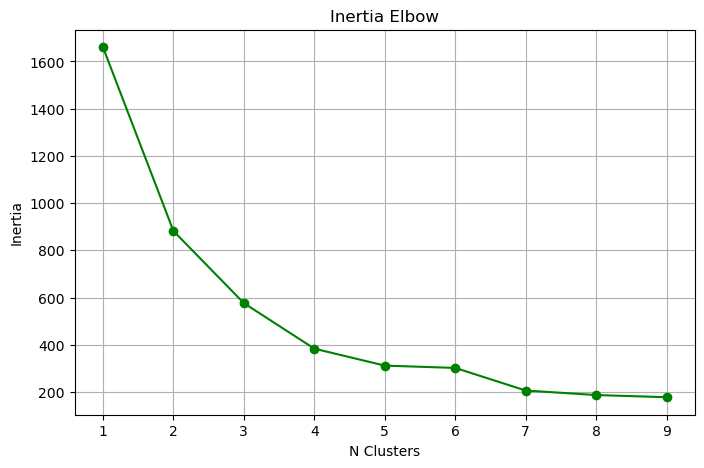

In [96]:
def find_optimal_n_clusters(df):
    inertias = dict()
    for i in range(1, 10):
        KM = KMeans(n_clusters=i, random_state=42)
        KM.fit(df)
        inertias[i] = KM.inertia_

    keys = list(inertias.keys())
    values = list(inertias.values())

    plt.figure(figsize=(8, 5))
    plt.plot(keys, values, marker='o', color='green')
    plt.xlabel('N Clusters')
    plt.ylabel('Inertia')
    plt.title('Inertia Elbow')
    plt.grid(True)
    plt.show()
    # Optimal number of clusters = 4

find_optimal_n_clusters(s_df)

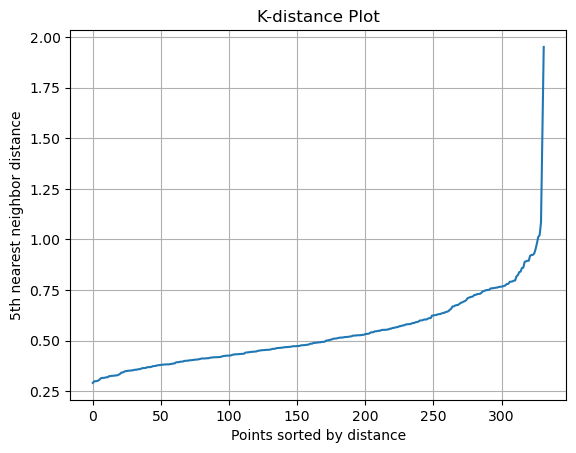

In [97]:
def plot_k_distance(df):
    neighbors = NearestNeighbors(n_neighbors=5)
    neighbors_fit = neighbors.fit(df)

    distances, indices = neighbors_fit.kneighbors(df)

    # Take the distance to the 5th neighbor
    distances = np.sort(distances[:, 4])

    plt.plot(distances)
    plt.xlabel("Points sorted by distance")
    plt.ylabel("5th nearest neighbor distance")
    plt.title("K-distance Plot")
    plt.grid(True)
    plt.show()

plot_k_distance(s_df)

In [98]:
def find_best_params_dbscan(df):

    epsilon = [0.75, 0.85, 0.95]
    min_samples = [3, 5, 7]

    best_score = -1
    best_params = None

    for eps in epsilon:
        for min_sample in min_samples:
            dbscan = DBSCAN(eps=eps, min_samples=min_sample)
            labels = dbscan.fit_predict(df)
            
            # Ignore cases where all points are labeled as noise (-1)
            if len(set(labels)) > 1:
                score = silhouette_score(df, labels)
                
                if score > best_score:
                    best_score = score
                    best_params = {'eps': eps, 'min_samples': min_sample}
 
    print(f'Best params: {best_params} with Silhouette Score: {best_score}')
    return best_params

dbscan_params = find_best_params_dbscan(s_df)


Best params: {'eps': 0.85, 'min_samples': 3} with Silhouette Score: 0.505016937092684


Now, I will train and compare all models. KMeans will be trained with 4 clusters, since that was the optimal number of cluster found with the elbow plot technique.

In [99]:
def train_kmeans(df, return_model):

    KM = KMeans(n_clusters=4, random_state=42)
    KM.fit(df)
    labels = KM.labels_
    
    if return_model == True:
        return KM
    return (f'Silhouette Score = {silhouette_score(df, labels):.3f}, n clusters = 4')

def train_MS(df, return_model):
    
    bandwidth = estimate_bandwidth(df, quantile=0.2)

    MS = MeanShift(bandwidth=bandwidth).fit(df)
    labels = MS.labels_
    n_clusters = len(set(labels))

    if return_model == True:
        return MS
    return (f'Silhouette Score = {silhouette_score(df, labels):.3f}, n clusters = {n_clusters}')

def train_DBSCAN(df, params, return_model):

    dbscan = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = dbscan.fit_predict(df)

    # The -1 label stands for noise classification. Noise points are removed for cluster counting
    # and silhouette score calculation.

    unique_labels = set(labels)

    if -1 in unique_labels:
        unique_labels.remove(-1)
    n_clusters = len(unique_labels)

    if return_model:
        return dbscan
    
    # Remove noise points
    mask = labels != -1
    filtered_df = df[mask]
    filtered_labels = labels[mask]

    if len(set(filtered_labels)) < 2:
        return f'Invalid clustering configuration, n clusters = {n_clusters}'

    score = silhouette_score(filtered_df, filtered_labels)

    return (f'Silhouette Score = {score:.3f}, n clusters = {n_clusters}')

def train_models(df):
    results = dict()
    results['K-Means'] = train_kmeans(df, False)
    results['Mean Shift'] = train_MS(df, False)
    results['DBSCAN'] = train_DBSCAN(df, dbscan_params, False)
    return results

# Train different models and return their Silhouette Score to compare their performance
model_scores = train_models(s_df)
model_scores

{'K-Means': 'Silhouette Score = 0.509, n clusters = 4',
 'Mean Shift': 'Silhouette Score = 0.509, n clusters = 4',
 'DBSCAN': 'Silhouette Score = 0.514, n clusters = 4'}

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). Ranges from -1 to 1, where a value close to 1 indicates that the sample is well clustered. The best performing algorithm in this case is DBSCAN.



Step 6. Visualize Clustering

Since visualizing more than 3 dimensions is impossible, PCA will be applied to the dataset only for visualization purposes, reducing the feature space to 3 dimensions.

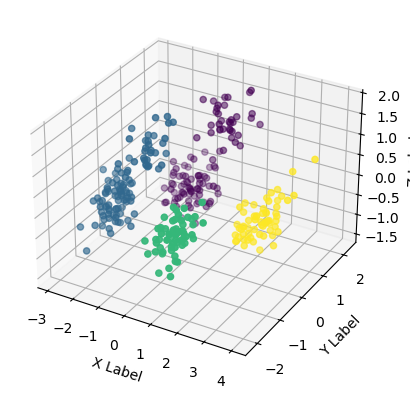

In [102]:
def plot_clusters(model, df, include_centers, has_noise=False):

    labels = model.labels_
    
    # Build mask for non-noise points
    if has_noise:
        mask = labels != -1
        df = df[mask].copy()
        labels = labels[mask]

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot the data points with different colors based on their cluster label
    ax.scatter(df['PC1'], df['PC2'], df['PC3'], c=labels, cmap='viridis', marker='o')

    # Plot the cluster centers with a different marker
    if include_centers == True:
        centers = model.cluster_centers_
        ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='red', marker='x', s=100, label='Centers')

    ax.set_xlabel('X Label')
    ax.set_ylabel('Y Label')
    ax.set_zlabel('Z Label')
    
    if include_centers ==True:
        plt.legend()
    
    plt.show()

pca = PCA(n_components = 3)
pca_array = pca.fit_transform(s_df)
pca_df = pd.DataFrame(pca_array, columns=[f'PC{i+1}' for i in range(pca_array.shape[1])])

dbscan_model = train_DBSCAN(pca_df, dbscan_params, True)
plot_clusters(dbscan_model, pca_df, False, True)

We can also visualize how other models clustered the data points.

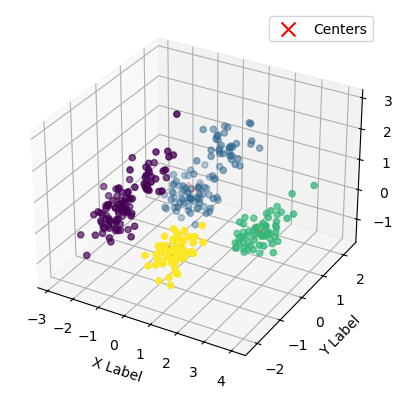

In [103]:
MS_model = train_MS(pca_df, True)
plot_clusters(MS_model, pca_df, True)

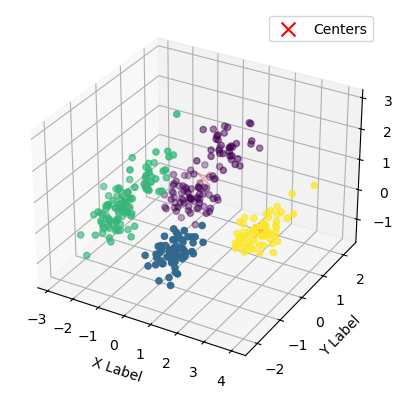

In [104]:
Kmeans_model = train_kmeans(pca_df, True)
plot_clusters(Kmeans_model, pca_df, True)